**path and reading file**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# لإظهار الرسومات بجودة عالية
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print(f"Current Directory: {os.getcwd()}")

print(f"Files in current directory: {os.listdir('.')}")

try:
    df = pd.read_csv('data/raw/train.csv') 
    print(df.head())
    print("Success! Data loaded.")
except FileNotFoundError:
    print("Still can't find it.")

Current Directory: d:\Fraud_Detection_System_End_to_End_ML_Project
Files in current directory: ['.git', 'api', 'config', 'data', 'main.py', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'venv']
       Time        V1        V2        V3        V4        V5        V6  \
0  119191.0  2.052427 -0.133236 -1.740621  0.277935  0.337999 -0.826933   
1   71750.0  1.220356 -0.159191 -0.444349 -0.094437  0.104457 -0.345790   
2  151977.0  0.892824 -1.440698 -0.637940  3.912871  0.099291  2.433288   
3   55709.0 -3.146021  2.247634  0.901397  0.146162 -2.109360 -0.148312   
4   66654.0  1.194996 -0.007495  0.301285  0.750199 -0.297494 -0.405836   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.334629 -0.227039  0.267655  ... -0.006518  0.121300  0.037733 -0.356498   
1  0.170867 -0.094996  0.187572  ... -0.088775 -0.364654 -0.140851 -0.707308   
2 -0.308891  0.603227 -0.113826  ...  0.484969  0.487304 -0.122694 -0.598803   
3 -1.53

**Data Overview**

In [2]:
df.shape

(170884, 31)

Data contains 30 features(28 are anonymous, 2 are time and amount) and 1 target(fraud(1) or not(0))
170884 samples which is good amount of data!

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170884 entries, 0 to 170883
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170884 non-null  float64
 1   V1      170884 non-null  float64
 2   V2      170884 non-null  float64
 3   V3      170884 non-null  float64
 4   V4      170884 non-null  float64
 5   V5      170884 non-null  float64
 6   V6      170884 non-null  float64
 7   V7      170884 non-null  float64
 8   V8      170884 non-null  float64
 9   V9      170884 non-null  float64
 10  V10     170884 non-null  float64
 11  V11     170884 non-null  float64
 12  V12     170884 non-null  float64
 13  V13     170884 non-null  float64
 14  V14     170884 non-null  float64
 15  V15     170884 non-null  float64
 16  V16     170884 non-null  float64
 17  V17     170884 non-null  float64
 18  V18     170884 non-null  float64
 19  V19     170884 non-null  float64
 20  V20     170884 non-null  float64
 21  V21     170884 non-nu

float64(30) features, int64(1) target>> Data is ready, no null values at first look.

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,...,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000
mean,94966.107886,-0.001070,-0.000904,-0.002722,-0.002603,0.000151,0.000779,-0.000811,-0.002327,-0.000622,...,0.000957,0.000056,0.000475,-0.000894,-0.000593,-0.000738,0.000404,0.000422,88.511723,0.001785
std,47464.723773,1.958944,1.650481,1.521820,1.416490,1.394123,1.338331,1.260122,1.208709,1.098393,...,0.743974,0.726681,0.620647,0.605148,0.521128,0.481720,0.404540,0.314973,256.737144,0.042210
min,0.000000,-46.855047,-63.344698,-48.325589,-5.683171,-113.743307,-23.496714,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-36.666000,-2.836627,-7.081325,-2.604551,-9.895244,-15.430084,0.000000,0.000000
25%,54348.000000,-0.922071,-0.599127,-0.896376,-0.848978,-0.691840,-0.768986,-0.554440,-0.209596,-0.642036,...,-0.228068,-0.542831,-0.161063,-0.354552,-0.318057,-0.327631,-0.070719,-0.053019,5.637500,0.000000
50%,84923.500000,0.016603,0.065839,0.177007,-0.020895,-0.054185,-0.274228,0.040417,0.021461,-0.051777,...,-0.029547,0.006488,-0.010688,0.040433,0.016916,-0.051262,0.001520,0.011216,22.020000,0.000000
75%,139404.000000,1.316250,0.802518,1.028302,0.738812,0.612154,0.400359,0.569221,0.326026,0.595095,...,0.186681,0.528971,0.147814,0.437888,0.350188,0.240718,0.091713,0.078480,77.650000,0.000000
max,172792.000000,2.451888,22.057729,4.226108,16.875344,34.099309,73.301626,120.589494,18.282168,10.392889,...,27.202839,10.503090,22.528412,4.584549,6.070850,3.517346,31.612198,16.129609,25691.160000,1.000000


At first glance, mean value of Class(target,where 1 is fraud transaction)=0.001785, there is a severe imbalanced class, 
Also, there is an outlier at Amount feature,


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

No missing values at all!

In [6]:
duplicates=df.duplicated().sum()
print(duplicates)

448


In [7]:
print(f"Percentage: {duplicates / len(df) * 100:.4f}%")

Percentage: 0.2622%


448 duplicated transactions, only 0.26%, we can drop them 

In [8]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

No duplicates now!

**Target Analysis**

In [9]:
fraud_count = df['Class'].value_counts()
fraud_percentage = df['Class'].value_counts(normalize=True) * 100

print(f"Counts:\n{fraud_count}")
print(f"\nPercentages:\n{fraud_percentage}")

Counts:
Class
0    170139
1       297
Name: count, dtype: int64

Percentages:
Class
0    99.825741
1     0.174259
Name: proportion, dtype: float64


Accuracy metric will be misleading in this case!

**Numerical Features Distribution**

In [16]:
df['hour'] = ((df['Time'] // 3600) % 24).astype(int)
df['hour']

0          9
1         19
2         18
3         15
4         18
          ..
170879    14
170880     1
170881    20
170882     9
170883    12
Name: hour, Length: 170436, dtype: int64

created new feature converting time in seconds to hours from 0 to 23 for making analysis easier

In [20]:
df.loc[df['Class'] == 1, 'hour'].value_counts().sort_index()

hour
0      5
1      8
2     32
3     10
4     15
5      7
6      4
7     16
8      5
9      9
10     2
11    31
12    11
13     9
14    12
15    18
16    15
17    16
18    18
19    15
20    13
21     8
22     9
23     9
Name: count, dtype: int64

<Axes: xlabel='hour', ylabel='Count'>

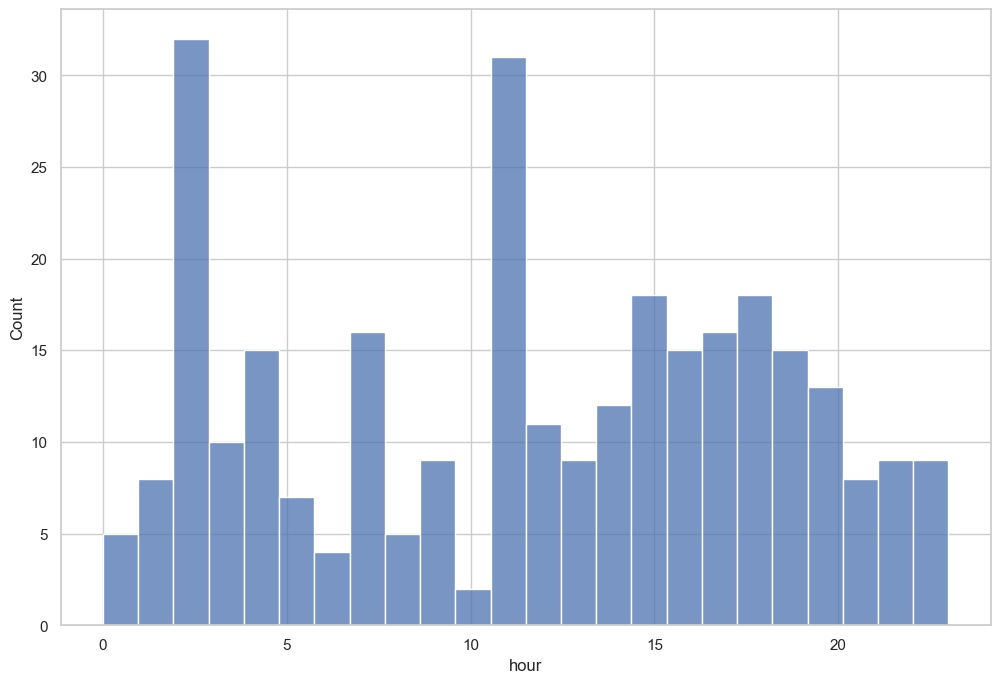

In [21]:
sns.histplot(data=df[df['Class']==1], x='hour', bins=24)

At 2 o'clock, 11 o'clock>> 31 fraud.
The "Dead of Night" Spike (02:00 AM):exploit the low surveillance period
The "Peak Hour" Camouflage (11:00 AM): Hide in the Crowd